
# Cash position EDA — daily party balances vs box-level motor

Objetivo: entender con precisión la relación entre:

- `daily_cash_position.csv`: posiciones diarias por `Box / party / Currency`.
- `box_balance_time_long.freq=M.csv`: motor mensual de caja por `Box / Currency`, con `net` y `cum_net`.

Esta notebook está pensada para apoyar los drilldowns de:

- `monthly_tables_cash_close_matrix`
- `monthly_tables_diagnostic_box_level_matrix`

La distinción clave que vamos a auditar:

```text
party-level internal balances ≠ box-level cash close
```

Para drilldown de `cash_close`, normalmente queremos la fila **box-level** (`cum_net` / motor), no todas las filas internas por `party`.


In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys


pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

warnings.filterwarnings("ignore", category=FutureWarning)



In [5]:

# Path resolution: works both inside the repo and with uploaded sandbox files.
CANDIDATES = {
    "daily_cash_position": [
        Path("/home/matias/repos/accounting-backend/out/run/accounting/latest/daily_cash_position.csv"),
        # out/run/accounting/latest/daily_cash_position.csv
        Path("/mnt/data/daily_cash_position.csv"),
        Path("daily_cash_position.csv"),
    ],
    "box_balance_m": [
        Path("/home/matias/repos/accounting-backend/out/run/accounting/latest/box_balance_time_long.freq=M.csv"),
        Path("/mnt/data/box_balance_time_long.freq=M.csv"),
        Path("box_balance_time_long.freq=M.csv"),
    ],
}

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError("None of these paths exist: " + ", ".join(map(str, paths)))

PATH_DAILY = first_existing(CANDIDATES["daily_cash_position"])
PATH_BOX_M = first_existing(CANDIDATES["box_balance_m"])

PATH_DAILY, PATH_BOX_M


FileNotFoundError: None of these paths exist: ../../out/run/accounting/latest/box_balance_time_long.freq=M.csv, /mnt/data/box_balance_time_long.freq=M.csv, box_balance_time_long.freq=M.csv

In [3]:

def load_daily(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["period"] = df["Date"].dt.to_period("M").astype(str)
    df["balance"] = pd.to_numeric(df["balance"], errors="coerce").fillna(0.0)
    for col in ["Box", "party", "Currency"]:
        df[col] = df[col].astype("string")
    return df

def load_box_m(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.rename(columns={
        "TimePeriod": "period",
        "TimePeriod_end": "period_end",
        "cum_net": "box_cash_close",
        "net": "diagnostic_box_level",
    })
    df["period_end"] = pd.to_datetime(df["period_end"], errors="coerce")
    for col in ["in_amt", "out_amt", "diagnostic_box_level", "box_cash_close"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    for col in ["Box", "Currency"]:
        df[col] = df[col].astype("string")
    return df

daily = load_daily(PATH_DAILY)
box_m = load_box_m(PATH_BOX_M)

print("daily:", daily.shape, PATH_DAILY)
print("box_m:", box_m.shape, PATH_BOX_M)

display(daily.head())
display(box_m.head())


daily: (62358, 7) ../../out/run/accounting/latest/daily_cash_position.csv
box_m: (161, 8) ../../out/run/accounting/latest/box_balance_time_long.freq=M.csv


,Date,Box,party,Currency,balance,source_ledger_hash,period
0,2022-01-10,Family Business,Alejandro,ARS,0.00,NaN,2022-01
1,2022-01-11,Family Business,Alejandro,ARS,0.00,NaN,2022-01
2,2022-01-12,Family Business,Alejandro,ARS,0.00,NaN,2022-01
3,2022-01-13,Family Business,Alejandro,ARS,0.00,NaN,2022-01
4,2022-01-14,Family Business,Alejandro,ARS,0.00,NaN,2022-01


,period,period_end,Box,Currency,in_amt,out_amt,diagnostic_box_level,box_cash_close
0,2022-01,2022-01-31,Family Business,ARS,"144,000.00","144,000.00",0.00,0.00
1,2022-02,2022-02-28,Family Business,ARS,"118,000.00","135,800.00","-17,800.00","-17,800.00"
2,2022-03,2022-03-31,Family Business,ARS,"118,000.00","100,200.00","17,800.00",0.00
3,2022-04,2022-04-30,Family Business,ARS,"438,152.00","438,152.00",0.00,0.00
4,2022-05,2022-05-31,Family Business,ARS,"438,152.00","438,152.00",0.00,0.00



## 1. Structural checks

Primero miramos si los archivos tienen el grano esperado y si hay duplicados en las claves naturales.

Grano esperado:

```text
daily_cash_position:
  Date / Box / party / Currency

box_balance_time_long.freq=M:
  period / Box / Currency
```


In [ ]:

def structural_summary(daily: pd.DataFrame, box_m: pd.DataFrame) -> None:
    print("DAILY date range:", daily["Date"].min(), "→", daily["Date"].max())
    print("DAILY boxes:", sorted(daily["Box"].dropna().unique()))
    print("DAILY currencies:", sorted(daily["Currency"].dropna().unique()))
    print("DAILY parties:", sorted(daily["party"].dropna().unique()))
    print("DAILY duplicate Date/Box/party/Currency rows:", daily.duplicated(["Date", "Box", "party", "Currency"]).sum())
    print()
    print("BOX_M period range:", box_m["period"].min(), "→", box_m["period"].max())
    print("BOX_M duplicate period/Box/Currency rows:", box_m.duplicated(["period", "Box", "Currency"]).sum())
    print()
    print("BOX_M rows by Box/Currency")
    display(box_m.groupby(["Box", "Currency"], dropna=False).size().rename("rows").reset_index())

structural_summary(daily, box_m)


NameError: name 'daily' is not defined


## 2. Month-end party balances vs box motor

`daily_cash_position` está a grano diario/party. Para compararlo contra un motor mensual, tomamos el último registro disponible de cada `party` dentro de cada mes.

Dos conceptos distintos:

```text
daily_party_eom_sum = suma de balances internos por party al cierre del mes
box_cash_close      = cum_net del motor mensual de caja por Box/Currency
diagnostic_box_level = net del mes; equivalente a delta mensual de box_cash_close
```

El `daily_party_eom_sum` puede ser útil para explicar la composición interna, pero no debería contaminar el drilldown principal del `cash_close` si el contrato de la tabla es box-level.


In [ ]:

daily_eom = (
    daily.sort_values("Date")
    .groupby(["period", "Box", "party", "Currency"], dropna=False)
    .tail(1)
    .copy()
)

party_sum = (
    daily_eom
    .groupby(["period", "Box", "Currency"], dropna=False)["balance"]
    .sum()
    .reset_index(name="daily_party_eom_sum")
)

box_month = box_m[[
    "period", "period_end", "Box", "Currency",
    "in_amt", "out_amt", "diagnostic_box_level", "box_cash_close",
]].copy()

compare = party_sum.merge(
    box_month,
    on=["period", "Box", "Currency"],
    how="outer",
    validate="one_to_one",
)

for col in ["daily_party_eom_sum", "box_cash_close", "diagnostic_box_level"]:
    compare[col] = pd.to_numeric(compare[col], errors="coerce").fillna(0.0)

compare["diff_party_sum_minus_box_close"] = compare["daily_party_eom_sum"] - compare["box_cash_close"]

display(compare.sort_values(
    "diff_party_sum_minus_box_close",
    key=lambda s: s.abs(),
    ascending=False,
).head(30))


NameError: name 'daily' is not defined


## 3. Focus case: drilldown target

Usamos un caso concreto para ver si el drilldown debería mostrar:

1. la fila box-level usada para reconciliar, y
2. las filas party-level como evidencia secundaria/excluida, no como matched detail principal.


In [ ]:

TARGET_PERIOD = "2023-06"
TARGET_BOX = "Property Management"
TARGET_CURRENCY = "ARS"

target_party_rows = daily_eom[
    daily_eom["period"].eq(TARGET_PERIOD)
    & daily_eom["Box"].eq(TARGET_BOX)
    & daily_eom["Currency"].eq(TARGET_CURRENCY)
].sort_values("party").copy()

target_box_row = box_month[
    box_month["period"].eq(TARGET_PERIOD)
    & box_month["Box"].eq(TARGET_BOX)
    & box_month["Currency"].eq(TARGET_CURRENCY)
].copy()

print("Party-level EOM rows")
display(target_party_rows)

print("Box-level monthly motor row")
display(target_box_row)

print("Reconciliation")
summary = pd.DataFrame([{
    "period": TARGET_PERIOD,
    "Box": TARGET_BOX,
    "Currency": TARGET_CURRENCY,
    "party_eom_sum": target_party_rows["balance"].sum(),
    "box_cash_close": target_box_row["box_cash_close"].sum(),
    "diagnostic_box_level": target_box_row["diagnostic_box_level"].sum(),
    "party_sum_minus_box_close": target_party_rows["balance"].sum() - target_box_row["box_cash_close"].sum(),
}])
display(summary)


NameError: name 'daily_eom' is not defined

In [ ]:

# Detail-shape recommendation for cash_close drilldown:
# matched_detail should be the box-level row; party-level rows can be shown as excluded/secondary evidence.

cash_close_detail_main = target_box_row.copy()
cash_close_detail_main["measure"] = "cash_close"
cash_close_detail_main["cash_close"] = cash_close_detail_main["box_cash_close"]

party_rows_excluded = target_party_rows.copy()
party_rows_excluded["excluded_from_reconciliation"] = True
party_rows_excluded["reason"] = "party-level internal balance; not box-level cash close row"

print("Matched detail rows for cash_close")
display(cash_close_detail_main)

print("Excluded/secondary party rows")
display(party_rows_excluded)


NameError: name 'target_box_row' is not defined


## 4. Visual EDA

Tres vistas útiles:

1. cash close mensual por Box/Currency,
2. diagnóstico mensual (`net`) por Box/Currency,
3. líneas diarias por party para un Box/Currency concreto.

La tercera vista ayuda a imaginar un drilldown gráfico posterior: una línea diaria por party y una línea mensual box-level.


In [ ]:

def plot_box_cash_close(box_m: pd.DataFrame, currency="ARS"):
    data = box_m[box_m["Currency"].eq(currency)].copy()
    data["period_dt"] = pd.to_datetime(data["period"] + "-01")

    plt.figure(figsize=(12, 5))
    for box, g in data.groupby("Box"):
        g = g.sort_values("period_dt")
        plt.plot(g["period_dt"], g["box_cash_close"], marker="o", linewidth=1, label=box)

    plt.title(f"Box-level cash close from monthly motor — {currency}")
    plt.xlabel("period")
    plt.ylabel("box_cash_close / cum_net")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_box_cash_close(box_m, currency="ARS")


NameError: name 'box_m' is not defined

In [ ]:

def plot_diagnostic_box_level(box_m: pd.DataFrame, box: str, currency: str):
    data = box_m[
        box_m["Box"].eq(box)
        & box_m["Currency"].eq(currency)
    ].copy()
    data["period_dt"] = pd.to_datetime(data["period"] + "-01")
    data = data.sort_values("period_dt")

    plt.figure(figsize=(12, 4))
    plt.bar(data["period_dt"], data["diagnostic_box_level"], width=20)
    plt.axhline(0, linewidth=1)
    plt.title(f"Monthly diagnostic box level / net — {box} / {currency}")
    plt.xlabel("period")
    plt.ylabel("diagnostic_box_level / net")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_diagnostic_box_level(box_m, TARGET_BOX, TARGET_CURRENCY)


NameError: name 'box_m' is not defined

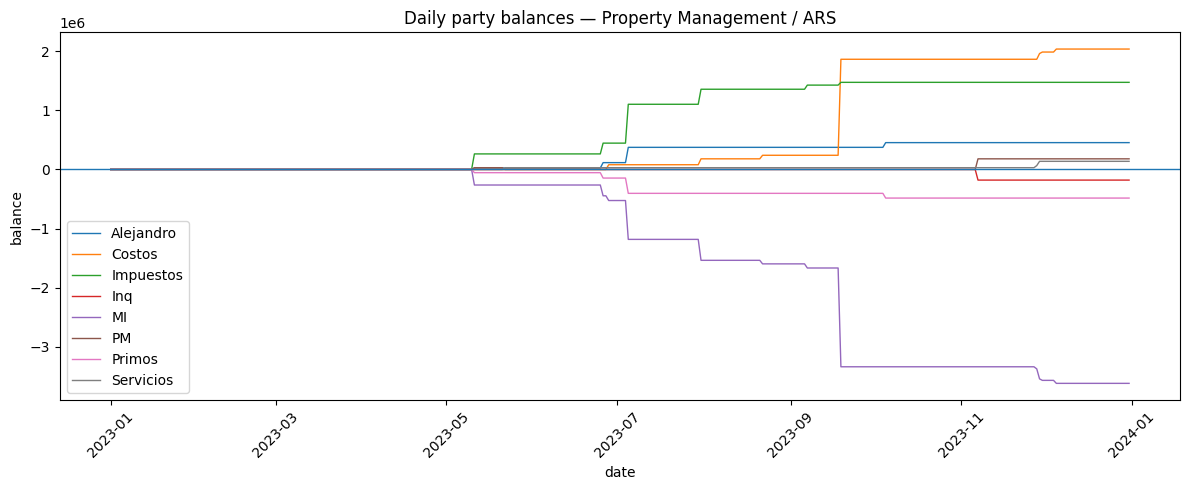

In [10]:

def plot_daily_parties(
    daily: pd.DataFrame,
    *,
    box: str,
    currency: str,
    start: str = "2023-01-01",
    end: str = "2023-12-31",
    max_parties: int = 8,
):
    data = daily[
        daily["Box"].eq(box)
        & daily["Currency"].eq(currency)
        & daily["Date"].between(pd.Timestamp(start), pd.Timestamp(end))
    ].copy()

    if data.empty:
        print("No data for selection.")
        return

    # Pick parties with largest absolute exposure in the window.
    party_rank = (
        data.groupby("party")["balance"]
        .apply(lambda s: s.abs().max())
        .sort_values(ascending=False)
        .head(max_parties)
        .index
    )

    data = data[data["party"].isin(party_rank)]

    plt.figure(figsize=(12, 5))
    for party, g in data.groupby("party"):
        g = g.sort_values("Date")
        plt.plot(g["Date"], g["balance"], linewidth=1, label=str(party))

    plt.axhline(0, linewidth=1)
    plt.title(f"Daily party balances — {box} / {currency}")
    plt.xlabel("date")
    plt.ylabel("balance")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_daily_parties(
    daily,
    box=TARGET_BOX,
    currency=TARGET_CURRENCY,
    start="2023-01-01",
    end="2023-12-31",
)



## 5. QA reports for drilldown design

Estos reportes ayudan a encontrar meses donde el drilldown podría confundirse si mezcla party-level y box-level rows.


In [11]:

# Biggest differences between party-level EOM sum and box-level cash close.
largest_diffs = compare.assign(
    abs_diff=lambda d: d["diff_party_sum_minus_box_close"].abs()
).sort_values("abs_diff", ascending=False)

display(largest_diffs.head(50))

# Months where box close is nonzero but party EOM sum is near zero:
box_nonzero_party_zero = compare[
    compare["box_cash_close"].abs().gt(1e-6)
    & compare["daily_party_eom_sum"].abs().le(1e-6)
].sort_values("box_cash_close", key=lambda s: s.abs(), ascending=False)

display(box_nonzero_party_zero.head(50))


,period,Box,Currency,daily_party_eom_sum,period_end,in_amt,out_amt,diagnostic_box_level,box_cash_close,diff_party_sum_minus_box_close,abs_diff
238,2025-12,Property Management,ARS,0.00,2025-12-31,"722,005.00","417,899.00","304,106.00","3,081,878.00","-3,081,878.00","3,081,878.00"
268,2026-06,Property Management,ARS,0.00,2026-06-30,"1,438,519.00","803,519.00","635,000.00","2,936,862.72","-2,936,862.72","2,936,862.72"
273,2026-07,Property Management,ARS,0.00,2026-07-31,0.00,"120,066.00","-120,066.00","2,816,796.72","-2,816,796.72","2,816,796.72"
233,2025-11,Property Management,ARS,0.00,2025-11-30,"781,334.00","46,334.00","735,000.00","2,777,772.00","-2,777,772.00","2,777,772.00"
263,2026-05,Property Management,ARS,0.00,2026-05-31,"1,284,384.00","960,338.28","324,045.72","2,301,862.72","-2,301,862.72","2,301,862.72"
228,2025-10,Property Management,ARS,0.00,2025-10-31,"1,446,334.00","665,000.00","781,334.00","2,042,772.00","-2,042,772.00","2,042,772.00"
258,2026-04,Property Management,ARS,0.00,2026-04-30,"802,000.00","244,100.00","557,900.00","1,977,817.00","-1,977,817.00","1,977,817.00"
271,2026-07,Household,ARS,0.00,2026-07-31,0.00,"62,895.23","-62,895.23","-1,713,758.99","1,713,758.99","1,713,758.99"
266,2026-06,Household,ARS,0.00,2026-06-30,"110,000.00","396,308.65","-286,308.65","-1,650,863.76","1,650,863.76","1,650,863.76"
253,2026-03,Property Management,ARS,0.00,2026-03-31,"512,325.00","264,325.00","248,000.00","1,419,917.00","-1,419,917.00","1,419,917.00"


,period,Box,Currency,daily_party_eom_sum,period_end,in_amt,out_amt,diagnostic_box_level,box_cash_close,diff_party_sum_minus_box_close
238,2025-12,Property Management,ARS,0.00,2025-12-31,"722,005.00","417,899.00","304,106.00","3,081,878.00","-3,081,878.00"
268,2026-06,Property Management,ARS,0.00,2026-06-30,"1,438,519.00","803,519.00","635,000.00","2,936,862.72","-2,936,862.72"
273,2026-07,Property Management,ARS,0.00,2026-07-31,0.00,"120,066.00","-120,066.00","2,816,796.72","-2,816,796.72"
233,2025-11,Property Management,ARS,0.00,2025-11-30,"781,334.00","46,334.00","735,000.00","2,777,772.00","-2,777,772.00"
263,2026-05,Property Management,ARS,0.00,2026-05-31,"1,284,384.00","960,338.28","324,045.72","2,301,862.72","-2,301,862.72"
228,2025-10,Property Management,ARS,0.00,2025-10-31,"1,446,334.00","665,000.00","781,334.00","2,042,772.00","-2,042,772.00"
258,2026-04,Property Management,ARS,0.00,2026-04-30,"802,000.00","244,100.00","557,900.00","1,977,817.00","-1,977,817.00"
271,2026-07,Household,ARS,0.00,2026-07-31,0.00,"62,895.23","-62,895.23","-1,713,758.99","1,713,758.99"
266,2026-06,Household,ARS,0.00,2026-06-30,"110,000.00","396,308.65","-286,308.65","-1,650,863.76","1,650,863.76"
253,2026-03,Property Management,ARS,0.00,2026-03-31,"512,325.00","264,325.00","248,000.00","1,419,917.00","-1,419,917.00"


In [12]:

# Check diagnostic identity: diagnostic_box_level should equal delta of box_cash_close by Box/Currency.
diag_check = box_m.sort_values(["Box", "Currency", "period"]).copy()
diag_check["box_cash_close_prev"] = (
    diag_check.groupby(["Box", "Currency"])["box_cash_close"].shift(1).fillna(0.0)
)
diag_check["computed_delta"] = diag_check["box_cash_close"] - diag_check["box_cash_close_prev"]
diag_check["delta_minus_reported_net"] = diag_check["computed_delta"] - diag_check["diagnostic_box_level"]

display(
    diag_check[
        diag_check["delta_minus_reported_net"].abs().gt(1e-6)
    ].sort_values("delta_minus_reported_net", key=lambda s: s.abs(), ascending=False)
)


,period,period_end,Box,Currency,in_amt,out_amt,diagnostic_box_level,box_cash_close,box_cash_close_prev,computed_delta,delta_minus_reported_net


In [13]:

# Optional: export compact debug tables for drilldown implementation.
OUT = Path("out/cash_position_eda")
OUT.mkdir(parents=True, exist_ok=True)

compare.to_csv(OUT / "cash_position_monthly_compare.csv", index=False)
largest_diffs.head(200).to_csv(OUT / "cash_position_largest_party_vs_box_diffs.csv", index=False)
diag_check.to_csv(OUT / "cash_position_diagnostic_identity_check.csv", index=False)

print("Wrote:", OUT)


Wrote: out/cash_position_eda



## Working conclusions

Use this as the implementation contract for drilldowns:

```text
monthly_tables_cash_close_matrix:
  matched detail = box-level monthly motor row
  source = box_balance_time_long.freq=M.csv / cum_net
  or monthly_cash_close.csv rows where source_type/position_type marks inferred_box_motor
  do not match all party-level internal balances

monthly_tables_diagnostic_box_level_matrix:
  matched detail = formula current box-level close - previous box-level close
  source = same box-level monthly motor rows
  show current and previous source rows separately

daily_cash_position.csv:
  useful for party composition and audit visuals
  not the primary matched grain for cash_close matrix cells
```

Possible next artifact: a richer drilldown page with a daily plot by party plus box-level monthly close markers.
